In [1]:
import sys, os; sys.path.insert(0, '..')
import random, logging, math
import pyzx as zx
from fractions import Fraction
from pyzx.gadget_extract import *
import matplotlib.pyplot as plt
import numpy as np
Z = zx.VertexType.Z
X = zx.VertexType.X
SE = zx.EdgeType.SIMPLE
HE = zx.EdgeType.HADAMARD
zx.settings.drawing_backend = 'matplotlib'

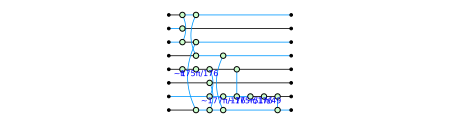

In [2]:
from importlib import reload
import approximate
reload(approximate)
from approximate import *
def random_control_phase(
        qubits: int,
        depth: int,
        p_noncliff: float = 0.2,
        p_cnot: float=0.2,
        p_cphase: float = 0.2,
        p_cliff: float = 0.2
        ) -> Circuit:

    p_had = 1-p_cphase-p_noncliff-p_cnot-p_cliff
    c = Circuit(qubits)
    for _ in range(depth):
        r = random.random()
        if r > 1-p_had:
            c.add_gate("HAD",random.randrange(qubits,))
        elif r > 1-p_had-p_cnot:
            tgt = random.randrange(qubits)
            while True:
                ctrl = random.randrange(qubits)
                if ctrl!=tgt: break
            c.add_gate("CNOT",tgt,ctrl)
        elif r > 1-p_had-p_cnot-p_noncliff:
            c.add_gate("ZPhase",random.randrange(qubits),phase=np.random.random()*2)
        elif r > 1-p_had-p_cnot-p_noncliff-p_cliff:
            p = random.choice([0,0.5,-0.5,1])
            if random.random() < 0.5:
                c.add_gate("ZPhase",random.randrange(qubits),p)
            else:
                c.add_gate("XPhase",random.randrange(qubits),p)
        else:
            tgt = random.randrange(qubits)
            while True:
                ctrl = random.randrange(qubits)
                if ctrl!=tgt: break
            c.add_gate("CPhase",tgt,ctrl,phase=np.random.random()*2)
    return c
c=random_control_phase(qubits=8, depth=10, p_noncliff = 0.1, p_cnot = 0.5, p_cphase = 0.1, p_cliff=0.1)
g = c.to_graph()
zx.to_gh(g)
zx.draw(g)

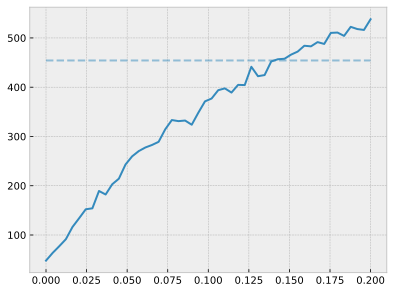

In [9]:
random.seed(1304)
np.random.seed(1304)

metric = 'twoqubit'
avg_count = []

for i in np.linspace(0,0.2):
    c_init_array = []
    for _ in range(10):
        c_init_array.append(random_control_phase(qubits=8, depth=1000, p_noncliff = i, p_cnot = 0.5, p_cphase = 0, p_cliff=0.1).to_basic_gates())

    inital_list = []
    for c_init in c_init_array:
        g = c_init.to_graph()
        zx.full_reduce(g)
        c = zx.extract_circuit(g)
        inital_list.append(c.stats_dict()[metric])
    avg_count.append(np.mean(inital_list))

basic_count = []
for c_init in c_init_array:
    g = c_init.to_graph()
    basic_simp_fast(g)
    c = zx.extract_circuit(g)
    basic_count.append(c.stats_dict()[metric])
avg_basic = np.mean(basic_count)

plt.hlines(avg_basic,xmin=0,xmax=0.2,linestyles='--', alpha=0.5, label='Original')
plt.plot(np.linspace(0,0.2),avg_count)

Err: 0.0
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
Err: 0.011111111111111112
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
Err: 0.022222222222222223
All gates would break error budget, nothing to squash.
Err: 0.03333333333333333
Err: 0.044444444444444446
Err: 0.05555555555555556
Err: 0.06666666666666667
Err: 0.077777

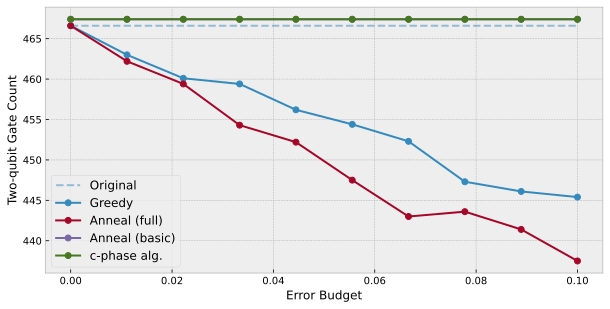

In [ ]:
random.seed(1304)
np.random.seed(1304)

err_budget_list = np.linspace(0,0.1,10)
metric = 'twoqubit'

avg_anneal_basic = []
avg_cphase = []
avg_inital = []
avg_greedy = []
avg_anneal_full = []
avg_anneal_basic = []
avg_cphase = []
avg_anneal_full_mean=[]
avg_anneal_full_min=[]

c_init_array = []
for i in range(10):
    c_init_array.append(random_control_phase(qubits=10, depth=1000, p_noncliff = 0.1, p_cnot = 0.5, p_cphase = 0, p_cliff=0.1).to_basic_gates())

for err_budget in err_budget_list:
    print(f"Err: {err_budget}")
    greedy_list = []
    anneal_full_mean = []
    anneal_full_min = []
    anneal_basic_list = []
    cphase_list = []
    inital_list = []
    anneal_basic_list = []
    cphase_list = []
    for c_init in c_init_array:
        g_init = c_init.to_graph()

        #### FULL REDUCE
        g = g_init.clone()
        zx.full_reduce(g)
        c = zx.extract_circuit(g)
        inital_list.append(c.stats_dict()[metric])

        ### GREEDY
        g = g_init.clone()
        zx.full_reduce(g)
        approximate(g, err_budget)
        c = zx.extract_circuit(g)
        greedy_list.append(c.stats_dict()[metric])

        ### ANNEAL (FULL)
        count_min = []
        anneal_count_intermediate = []
        for i in range(3):
            g = g_init.clone()
            zx.full_reduce(g)
            approximate_anneal(g, err_budget, quiet=True)
            c = zx.extract_circuit(g)
            anneal_count_intermediate.append(c.stats_dict()[metric])
        anneal_full_mean.append(np.mean(anneal_count_intermediate))
        anneal_full_mean.append(np.min(anneal_count_intermediate))
            
        ### ANNEAL (Basic)
        g = g_init.clone()
        basic_simp_fast(g)
        two_qubit_basic_anneal(g, err_budget, 10000, quiet=True)
        c = zx.extract_circuit(g)
        anneal_basic_list.append(c.stats_dict()[metric])

        ### CPhase Algorithm
        g = g_init.clone()
        basic_simp_fast(g)
        zx.to_gh(g)
        qft_two_qubit_approximation(g, err_budget)
        c = zx.extract_circuit(g)
        cphase_list.append(c.stats_dict()[metric])

    avg_inital.append(np.mean(inital_list))
    avg_greedy.append(np.mean(greedy_list))
    avg_anneal_full_mean.append(np.mean(anneal_full_mean))
    avg_anneal_full_min.append(np.mean(anneal_full_min))
    avg_anneal_basic.append(np.mean(anneal_basic_list))
    avg_cphase.append(np.mean(cphase_list))

fig, ax = plt.subplots()
plt.style.use('bmh')
ax.hlines(avg_inital[0],xmin=err_budget_list[0],xmax=err_budget_list[-1],linestyles='--', alpha=0.5, label='Original')
plt.plot(err_budget_list, avg_greedy, 'o-', label='Greedy', linewidth=2)
plt.plot(err_budget_list, avg_anneal_full, 'o-', label='Anneal (full)', linewidth=2)
plt.plot(err_budget_list, avg_anneal_basic, 'o-', label='Anneal (basic)', linewidth=2)
plt.plot(err_budget_list, avg_cphase, 'o-', label='c-phase alg.', linewidth=2)
plt.xlabel('Error Budget', size=12)
plt.ylabel('Two-qubit Gate Count', size=12)
plt.legend(fontsize=12)
fig.set_figwidth(10)

In [ ]:
random.seed(1304)
np.random.seed(1304)

err_budget_list = np.linspace(0,0.1,2)
metric = 'twoqubit'


avg_inital = []
avg_greedy = []
avg_anneal_full = []
avg_anneal_basic = []
avg_cphase = []

c_init_array = []
for i in range(5):
    c_init_array.append(random_control_phase(qubits=8, depth=1000, p_noncliff = 0.4, p_cnot = 0.4, p_cphase = 0).to_basic_gates())

for err_budget in err_budget_list:
    greedy_list = []
    anneal_full_list = []
    anneal_basic_list = []
    cphase_list = []
    inital_list = []
    for c_init in c_init_array:
        #### FULL REDUCE
        g = c_init.to_graph()
        basic_simp_fast(g)
        c = zx.extract_circuit(g)
        inital_list.append(c.stats_dict()[metric])

        ### GREEDY
        g = c_init.to_graph()
        basic_simp_fast(g)
        greedy_basic_reduce(g, err_budget)
        c = zx.extract_circuit(g.clone())
        greedy_list.append(c.stats_dict()[metric])

        ### ANNEAL (Basic)
        g = c_init.to_graph()
        basic_simp_fast(g)
        two_qubit_basic_anneal(g, err_budget, 10000, quiet=True)
        c = zx.extract_circuit(g)
        anneal_basic_list.append(c.stats_dict()[metric])

        ### CPhase Algorithm
        g = c_init.to_graph()
        basic_simp_fast(g)
        qft_two_qubit_approximation(g, err_budget)
        c = zx.extract_circuit(g)
        cphase_list.append(c.stats_dict()[metric])

    avg_inital.append(np.mean(inital_list))
    avg_greedy.append(np.mean(greedy_list))
    avg_anneal_basic.append(np.mean(anneal_basic_list))
    avg_cphase.append(np.mean(cphase_list))

fig, ax = plt.subplots()
plt.style.use('bmh')
ax.hlines(avg_inital[0],xmin=err_budget_list[0],xmax=err_budget_list[-1],linestyles='--', alpha=0.5, label='Original')
plt.plot(err_budget_list, avg_greedy, 'o-', label='Greedy', linewidth=2)
plt.plot(err_budget_list, avg_anneal_basic, 'o-', label='Anneal (basic)', linewidth=2)
plt.plot(err_budget_list, avg_cphase, 'o-', label='c-phase alg.', linewidth=2)
plt.xlabel('Error Budget', size=12)
plt.ylabel('Two-qubit Gate Count', size=12)
plt.legend(fontsize=12)
fig.set_figwidth(10)

All gates would break error budget, nothing to squash.


KeyError: 280

All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.


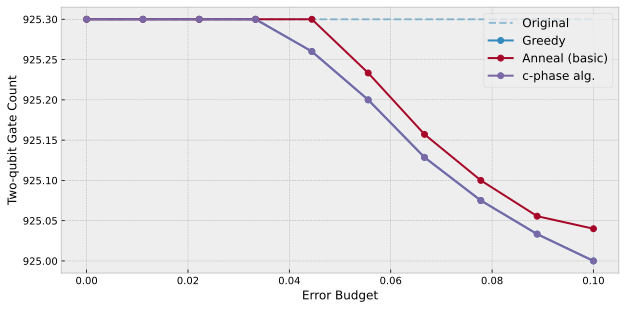

In [32]:
random.seed(1304)
np.random.seed(1304)

err_budget_list = np.linspace(0,0.1,10)
metric = 'twoqubit'
greedy_list = []
anneal_full_list = []
anneal_basic_list = []
cphase_list = []
inital_list = []

avg_inital = []
avg_greedy = []
avg_anneal_full = []
avg_anneal_basic = []
avg_cphase = []

c_init_array = []
for i in range(10):
    c_init_array.append(random_control_phase(qubits=8, depth=3000, p_noncliff = 0.33, p_cnot = 0.33, p_cphase = 0).to_basic_gates())

for err_budget in err_budget_list:
    for c_init in c_init_array:
        #### FULL REDUCE
        g = c_init.to_graph()
        basic_simp_fast(g)
        c = zx.extract_circuit(g)
        inital_list.append(c.stats_dict()[metric])

        ### GREEDY
        g = c_init.to_graph()
        basic_simp_fast(g)
        greedy_basic_reduce(g, err_budget)
        c = zx.extract_circuit(g.clone())
        greedy_list.append(c.stats_dict()[metric])

        ### ANNEAL (Basic)
        g = c_init.to_graph()
        basic_simp_fast(g)
        two_qubit_basic_anneal(g, err_budget, 10000, quiet=True)
        c = zx.extract_circuit(g)
        anneal_basic_list.append(c.stats_dict()[metric])

        ### CPhase Algorithm
        g = c_init.to_graph()
        basic_simp_fast(g)
        qft_two_qubit_approximation(g, err_budget)
        c = zx.extract_circuit(g)
        cphase_list.append(c.stats_dict()[metric])

    avg_inital.append(np.mean(inital_list))
    avg_greedy.append(np.mean(greedy_list))
    avg_anneal_basic.append(np.mean(anneal_basic_list))
    avg_cphase.append(np.mean(cphase_list))

fig, ax = plt.subplots()
plt.style.use('bmh')
ax.hlines(avg_inital[0],xmin=err_budget_list[0],xmax=err_budget_list[-1],linestyles='--', alpha=0.5, label='Original')
plt.plot(err_budget_list, avg_greedy, 'o-', label='Greedy', linewidth=2)
plt.plot(err_budget_list, avg_anneal_basic, 'o-', label='Anneal (basic)', linewidth=2)
plt.plot(err_budget_list, avg_cphase, 'o-', label='c-phase alg.', linewidth=2)
plt.xlabel('Error Budget', size=12)
plt.ylabel('Two-qubit Gate Count', size=12)
plt.legend(fontsize=12)
fig.set_figwidth(10)

Err: 0.0
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
Err: 0.011111111111111112
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
Err: 0.022222222222222223
Err: 0.03333333333333333
Err: 0.044444444444444446
Err: 0.05555555555555556
Err: 0.06666666666666667
Err: 0.07777777777777778
Err: 0.08888888888888889
Err: 0.1


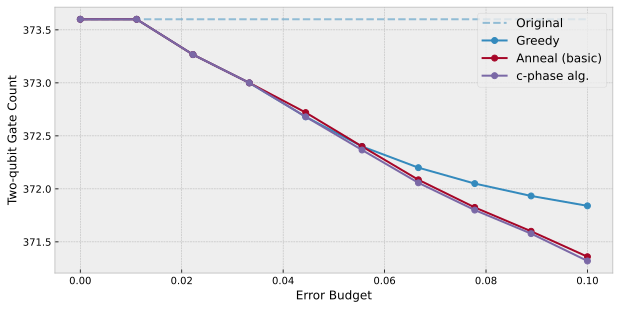

In [35]:
random.seed(1304)
np.random.seed(1304)

err_budget_list = np.linspace(0,0.1,10)
metric = 'twoqubit'
greedy_list = []
anneal_full_list = []
anneal_basic_list = []
cphase_list = []
inital_list = []

avg_inital = []
avg_greedy = []
avg_anneal_full = []
avg_anneal_basic = []
avg_cphase = []

c_init_array = []
for i in range(10):
    c_init_array.append(random_control_phase(qubits=8, depth=500, p_noncliff = 0.25, p_cnot = 0.25, p_cphase = 0.25).to_basic_gates())

for err_budget in err_budget_list:
    print(f"Err: {err_budget}")
    for c_init in c_init_array:
        #### FULL REDUCE
        g = c_init.to_graph()
        basic_simp_fast(g)
        c = zx.extract_circuit(g)
        inital_list.append(c.stats_dict()[metric])

        ### GREEDY
        g = c_init.to_graph()
        basic_simp_fast(g)
        greedy_basic_reduce(g, err_budget)
        c = zx.extract_circuit(g.clone())
        greedy_list.append(c.stats_dict()[metric])

        ### ANNEAL (Basic)
        g = c_init.to_graph()
        basic_simp_fast(g)
        two_qubit_basic_anneal(g, err_budget, 10000, quiet=True)
        c = zx.extract_circuit(g)
        anneal_basic_list.append(c.stats_dict()[metric])

        ### CPhase Algorithm
        g = c_init.to_graph()
        basic_simp_fast(g)
        qft_two_qubit_approximation(g, err_budget)
        c = zx.extract_circuit(g)
        cphase_list.append(c.stats_dict()[metric])

    avg_inital.append(np.mean(inital_list))
    avg_greedy.append(np.mean(greedy_list))
    avg_anneal_basic.append(np.mean(anneal_basic_list))
    avg_cphase.append(np.mean(cphase_list))

fig, ax = plt.subplots()
plt.style.use('bmh')
ax.hlines(avg_inital[0],xmin=err_budget_list[0],xmax=err_budget_list[-1],linestyles='--', alpha=0.5, label='Original')
plt.plot(err_budget_list, avg_greedy, 'o-', label='Greedy', linewidth=2)
plt.plot(err_budget_list, avg_anneal_basic, 'o-', label='Anneal (basic)', linewidth=2)
plt.plot(err_budget_list, avg_cphase, 'o-', label='c-phase alg.', linewidth=2)
plt.xlabel('Error Budget', size=12)
plt.ylabel('Two-qubit Gate Count', size=12)
plt.legend(fontsize=12)
fig.set_figwidth(10)

In [11]:
print(avg_anneal_basic)

[np.float64(223.6), np.float64(223.2), np.float64(222.93333333333334), np.float64(222.7), np.float64(222.24)]


[np.float64(381.0), np.float64(381.0), np.float64(380.0), np.float64(379.5), np.float64(379.2), np.float64(379.0), np.float64(378.85714285714283), np.float64(378.3125), np.float64(377.8888888888889), np.float64(377.55)]


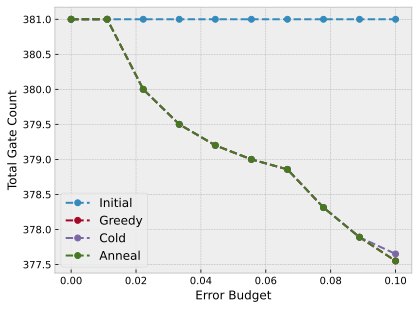

In [ ]:
random.seed(1304)
np.random.seed(1304)

err_budget_list = np.linspace(0,0.1,10)
metric = 'gates'
greedy_list = []
cold_list = []
anneal_list = []
inital_list = []

avg_inital = []
avg_cold = []
avg_greedy = []
avg_anneal = []

c_init_array = []
for i in range(2):
    c_init_array.append(random_control_phase(qubits=6, depth=200, p_noncliff = 0.3, p_cnot = 0, p_cphase = 0.5).to_basic_gates())

for err_budget in err_budget_list:
    for c_init in c_init_array:
        ### FULL REDUCE
        g = c_init.to_graph()
        zx.full_reduce(g)
        c = zx.extract_circuit(g)
        inital_list.append(c.stats_dict()[metric])

        ### GREEDY
        g = c_init.to_graph()
        zx.full_reduce(g)
        approximate(g, err_budget)
        c = zx.extract_circuit(g.clone())
        greedy_list.append(c.stats_dict()[metric])

        ### ANNEAL (ALGORITHM COLD)
        g = c_init.to_graph()
        zx.full_reduce(g)
        approximate_anneal(g, err_budget, quiet=True, cold=True)
        c = zx.extract_circuit(g)
        cold_list.append(c.stats_dict()[metric])

        ### ANNEAL (HOT)
        g = c_init.to_graph()
        zx.full_reduce(g)
        approximate_anneal(g, err_budget, quiet=True)
        c = zx.extract_circuit(g)
        anneal_list.append(c.stats_dict()[metric])

    avg_inital.append(np.mean(inital_list))
    avg_greedy.append(np.mean(greedy_list))
    avg_cold.append(np.mean(cold_list))
    avg_anneal.append(np.mean(anneal_list))

plt.style.use('bmh')
plt.plot(err_budget_list, avg_inital, 'o-', label='Initial', linewidth=2)
plt.plot(err_budget_list, avg_greedy, 'o-', label='Greedy', linewidth=2)
plt.plot(err_budget_list, avg_cold, 'o-', label='Cold', linewidth=2)
plt.plot(err_budget_list, avg_anneal, 'o-', label='Anneal', linewidth=2)
plt.xlabel('Error Budget',fontsize=12)
plt.ylabel('Total Gate Count',fontsize=12)
plt.legend(fontsize=12)

print(avg_greedy)

All gates would break error budget, nothing to squash.
Finished benchmarking: 0.0
Finished benchmarking: 0.1111111111111111
Finished benchmarking: 0.2222222222222222
Finished benchmarking: 0.3333333333333333
Finished benchmarking: 0.4444444444444444
Finished benchmarking: 0.5555555555555556
Finished benchmarking: 0.6666666666666666
Finished benchmarking: 0.7777777777777777
Finished benchmarking: 0.8888888888888888
Finished benchmarking: 1.0
[56, 56]
[56, 48, 44, 42, 40, 38, 38, 38, 36, 34]
[56, 52, 50, 46, 44, 44, 42, 42, 40, 40]


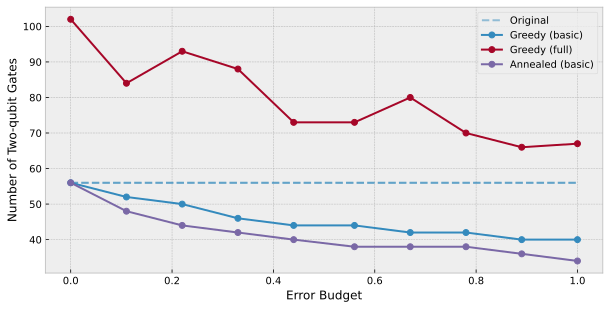

In [6]:
def anneal_greedy_algorithm_comp(circuit, err_budget_array, max_iter = 10000):
    # Set up dictionaries to store data
    bench_dict_anneal = {}
    bench_dict_greedy = {}
    bench_dict_full_greedy = {}
    bench_dict_original = {}

    total_error_anneal_list = []
    total_error_greedy_list = []
    total_error_full_greedy_list = []

    # Initial circuits data
    c = zx.Circuit.load(circuit)
    g = c.to_graph()
    circ_to_graph_to_circ = zx.extract_circuit(g)
    bench_dict_original["Original"] = c.stats_dict()
    bench_dict_original["0"] = circ_to_graph_to_circ.stats_dict()

    # Iterate through each error
    for err_budget in err_budget_array:
        # Run for anneal
        c = zx.Circuit.load(circuit)
        g = c.to_graph()
        total_error_anneal = two_qubit_basic_anneal(g, err_budget=err_budget, max_iter=10000, quiet=True)
        total_error_anneal_list.append(total_error_anneal)
        c = zx.extract_circuit(g)
        bench_dict_anneal[f'{err_budget}'] = c.stats_dict()

        # Run for greedy
        c = zx.Circuit.load(circuit)
        g = c.to_graph()
        total_error_greedy = greedy_basic_reduce(g, err_budget=err_budget, quiet=True)
        total_error_greedy_list.append(total_error_greedy)
        c = zx.extract_circuit(g)
        bench_dict_greedy[f'{err_budget}'] = c.stats_dict()

        # Run for full reduce greedy
        c = zx.Circuit.load(circuit)
        g = c.to_graph()
        total_error_full_greedy = greedy_full_reduce(g, err_budget=err_budget, quiet=True)
        total_error_full_greedy_list.append(total_error_full_greedy)
        c = zx.extract_circuit(g)
        bench_dict_full_greedy[f'{err_budget}'] = c.stats_dict()

        print(f'Finished benchmarking: {err_budget}')

    return (bench_dict_original, bench_dict_anneal, bench_dict_greedy, bench_dict_full_greedy, total_error_anneal_list,total_error_greedy_list,total_error_full_greedy_list)

circuit_QFT8 = r'circuits_for_benchmarking\QFT8_before'
err_budget_array = np.linspace(0,1,10)
bench_dict_original_QFT8, bench_dict_anneal_QFT8, bench_dict_greedy_QFT8, bench_dict_full_greedy_QFT8,total_error_anneal_list,total_error_greedy_list,total_error_full_greedy_list = anneal_greedy_algorithm_comp(circuit_QFT8, err_budget_array, max_iter = 10000)

# Plotting line chart
plt.style.use('bmh')
metric_to_plot = "twoqubit"

tq_count_original = [bench_dict_original_QFT8[str(err)][metric_to_plot] for err in ["Original", "0"]]
tq_count_anneal = [bench_dict_anneal_QFT8[str(err)][metric_to_plot] for err in err_budget_array]
tq_count_greedy = [bench_dict_greedy_QFT8[str(err)][metric_to_plot] for err in err_budget_array]
tq_count_full_greedy = [bench_dict_full_greedy_QFT8[str(err)][metric_to_plot] for err in err_budget_array]

print(tq_count_original)
print(tq_count_anneal)
print(tq_count_greedy)

x1 = np.arange(0, len(tq_count_anneal) + 2)
x2 = np.arange(0, len(tq_count_anneal)) + 2

fig, ax = plt.subplots()
err_budget_array_rounded = [float("%.2f" % i) for i in err_budget_array]
#plt.xticks(err_budget_array_rounded)

# Plot original as a dotted line
ax.hlines(tq_count_original,xmin=err_budget_array_rounded[0],xmax=err_budget_array_rounded[-1],linestyles='--', alpha=0.5, label='Original')

# Plot lines for each error budget
ax.plot(err_budget_array_rounded, tq_count_greedy, 'o-', label='Greedy (basic)')
ax.plot(err_budget_array_rounded, tq_count_full_greedy, 'o-', label='Greedy (full)')
ax.plot(err_budget_array_rounded, tq_count_anneal, 'o-', label='Annealed (basic)')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.xlabel('Error Budget')
plt.ylabel('Number of Two-qubit Gates')
fig.set_figwidth(10)
plt.savefig('qft8_benchmarking.png')
plt.show()

In [ ]:
circuit = r'circuits_for_benchmarking\QFT8_before'
c = zx.Circuit.load(circuit)
g = c.to_graph()
total_error_anneal = two_qubit_basic_anneal(g, err_budget=0.1, max_iter=10000, quiet=False)

In [ ]:
def anneal_greedy_algorithm_comp(circuit, err_budget_array, max_iter=10000, num_runs=5):
    bench_dict_original = {}
    bench_dict_anneal = {}
    bench_dict_greedy = {}
    total_error_greedy_list = []
    tq_count_anneal = []
    tq_count_anneal_min = []

    # Run for original
    c = zx.Circuit.load(circuit)
    bench_dict_original["Original"] = c.stats_dict()

    for err_budget in err_budget_array:
        # Run for anneal
        count = []
        min_count = float("inf")
        for _ in range(5):
            c = zx.Circuit.load(circuit)
            g = c.to_graph()
            total_error_anneal = two_qubit_basic_anneal(g, err_budget=err_budget, max_iter=10000, quiet=True)
            #total_error_anneal_list.append(total_error_anneal)
            c = zx.extract_circuit(g)
            bench_dict_anneal[f'{err_budget}'] = c.stats_dict()
            count.append(c.stats_dict()["twoqubit"])
            if c.stats_dict()["twoqubit"] < min_count:
                min_count = c.stats_dict()["twoqubit"]
        tq_count_anneal.append(np.mean(count))
        tq_count_anneal_min.append(min_count)

        # Run for greedy
        c = zx.Circuit.load(circuit)
        g = c.to_graph()
        total_error_greedy = greedy_basic_reduce(g, err_budget=err_budget)
        total_error_greedy_list.append(total_error_greedy)
        c = zx.extract_circuit(g)
        bench_dict_greedy[f'{err_budget}'] = c.stats_dict()

        print(f'Finished benchmarking: {err_budget}')

    return (bench_dict_original, tq_count_anneal, bench_dict_greedy, tq_count_anneal_min)

circuit_QFT8 = r'circuits_for_benchmarking\QFT8_before'
err_budget_array = np.linspace(0, 1, 10)
num_runs = 5  # Number of runs to average

bench_dict_original_QFT8, tq_count_anneal, bench_dict_greedy_QFT8, tq_count_anneal_min = anneal_greedy_algorithm_comp(circuit_QFT8, err_budget_array, max_iter=10000, num_runs=num_runs)

# Plotting line chart
plt.style.use('bmh')
metric_to_plot = "twoqubit"

tq_count_greedy = [bench_dict_greedy_QFT8[str(err)][metric_to_plot] for err in err_budget_array]

print(tq_count_original)
print(tq_count_anneal)
print(tq_count_greedy)
#print(tq_count_anneal_min)

x1 = np.arange(0, len(tq_count_anneal) + 2)
x2 = np.arange(0, len(tq_count_anneal)) + 2

fig, ax = plt.subplots()
err_budget_array_rounded = [float("%.2f" % i) for i in err_budget_array]
#plt.xticks(err_budget_array_rounded)

# Plot original as a dotted line
ax.hlines(tq_count_original, xmin=err_budget_array_rounded[0], xmax=err_budget_array_rounded[-1], linestyles='--', alpha=0.5, label='Original')

# Plot lines for each error budget
ax.plot(err_budget_array_rounded, tq_count_greedy, 'o-', label='Greedy (basic)')
#ax.plot(err_budget_array_rounded, tq_count_anneal_min, 'o-', label='Annealed min. (basic)')
ax.plot(err_budget_array_rounded, tq_count_anneal, 'o-', label='Annealed avg. (basic)')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.xlabel('Error Budget')
plt.ylabel('Number of Two-qubit Gates')
fig.set_figwidth(10)
plt.savefig('qft8_benchmarking.png')
plt.show()

All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.
All gates would break error budget, nothing to squash.


TypeError: greedy_basic_reduce() got an unexpected keyword argument 'quiet'

In [ ]:
def anneal_greedy_algorithm_comp(circuit, err_budget_array, max_iter=10000, num_runs=5):
    bench_dict_original = {}
    bench_dict_anneal = {}
    bench_dict_greedy = {}
    total_error_greedy_list = []
    tq_count_anneal = []
    tq_count_anneal_min = []

    # Run for original
    c = zx.Circuit.load(circuit)
    bench_dict_original["Original"] = c.stats_dict()

    for err_budget in err_budget_array:
        '''# Run for anneal
        count = []
        min_count = float("inf")
        for _ in range(1):
            c = zx.Circuit.load(circuit)
            g = c.to_graph()
            total_error_anneal = two_qubit_basic_anneal(g, err_budget=err_budget, max_iter=10000, quiet=True)
            total_error_anneal_list.append(total_error_anneal)
            c = zx.extract_circuit(g)
            bench_dict_anneal[f'{err_budget}'] = c.stats_dict()
            count.append(c.stats_dict()["twoqubit"])
            if c.stats_dict()["twoqubit"] < min_count:
                min_count = c.stats_dict()["twoqubit"]
        tq_count_anneal.append(np.mean(count))
        tq_count_anneal_min.append(min_count)'''

        # Run for greedy
        c = zx.Circuit.load(circuit)
        g = c.to_graph()
        total_error_greedy = qft_two_qubit_approximation(g, err_budget=err_budget)
        total_error_greedy_list.append(total_error_greedy)
        c = zx.extract_circuit(g)
        bench_dict_greedy[f'{err_budget}'] = c.stats_dict()

        # Run for greedy
        c = zx.Circuit.load(circuit)
        g = c.to_graph()
        total_error_greedy = greedy_basic_reduce(g, err_budget=err_budget, quiet=True)
        total_error_greedy_list.append(total_error_greedy)
        c = zx.extract_circuit(g)
        bench_dict_greedy[f'{err_budget}'] = c.stats_dict()

        print(f'Finished benchmarking: {err_budget}')

    return (bench_dict_original, tq_count_anneal, bench_dict_greedy, tq_count_anneal_min)

circuit_QFT8 = r'circuits_for_benchmarking\QFT16_before'
err_budget_array = np.linspace(0, 0.1, 5)
err_budget_array = [0.05]
num_runs = 5  # Number of runs to average

bench_dict_original_QFT8, tq_count_anneal, bench_dict_greedy_QFT8, tq_count_anneal_min = anneal_greedy_algorithm_comp(circuit_QFT8, err_budget_array, max_iter=10000, num_runs=num_runs)

NameError: name 'qft_two_qubit_approximation' is not defined

[np.float64(228.0), np.float64(195.6), np.float64(185.6), np.float64(182.8), np.float64(178.8)]
[228, 226, 224, 222, 218]
[228, 194, 184, 174, 172]


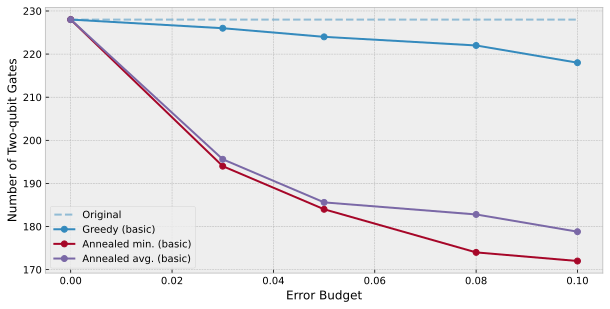

In [ ]:
# Plotting line chart
plt.style.use('bmh')
metric_to_plot = "twoqubit"

circuit_QFT8 = r'circuits_for_benchmarking\QFT16_before'
c = zx.Circuit.load(circuit_QFT8)
tq_count_original = c.stats_dict()["twoqubit"]

tq_count_greedy = [bench_dict_greedy_QFT8[str(err)][metric_to_plot] for err in err_budget_array]

print(tq_count_anneal)
print(tq_count_greedy)
print(tq_count_anneal_min)

x1 = np.arange(0, len(tq_count_anneal) + 2)
x2 = np.arange(0, len(tq_count_anneal)) + 2

fig, ax = plt.subplots()
err_budget_array_rounded = [float("%.2f" % i) for i in err_budget_array]
#plt.xticks(err_budget_array_rounded)

# Plot original as a dotted line
ax.hlines(tq_count_original, xmin=err_budget_array_rounded[0], xmax=err_budget_array_rounded[-1], linestyles='--', alpha=0.5, label='Original')

# Plot lines for each error budget
ax.plot(err_budget_array_rounded, tq_count_greedy, 'o-', label='Greedy (basic)')
ax.plot(err_budget_array_rounded, tq_count_anneal_min, 'o-', label='Annealed min. (basic)')
ax.plot(err_budget_array_rounded, tq_count_anneal, 'o-', label='Annealed avg. (basic)')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.xlabel('Error Budget')
plt.ylabel('Number of Two-qubit Gates')
fig.set_figwidth(10)
plt.savefig('qft8_benchmarking.png')
plt.show()

In [54]:
random.seed(1304)
np.random.seed(1304)

err_budget_list = np.linspace(0,0.1,5)
metric = 'gates'
greedy_list = []
cold_list = []
anneal_list = []
inital_list = []

avg_inital = []
avg_cold = []
avg_greedy = []
avg_anneal = []

circ_dict = {}
for i in range(1):
    circ_dict[i] = random_control_phase(qubits=7, depth=300, p_noncliff = 0.3, p_cnot = 0, p_cphase = 0.3).to_basic_gates()

for err_budget in err_budget_list:
    for i in range(1):
        c_init = circ_dict[i]
    
        ### FULL REDUCE
        g = c_init.to_graph()
        zx.full_reduce(g)
        c = zx.extract_circuit(g)
        inital_list.append(c.stats_dict()[metric])

        ### GREEDY
        g = c_init.to_graph()
        zx.full_reduce(g)
        approximate(g, err_budget)
        c = zx.extract_circuit(g.clone())
        greedy_list.append(c.stats_dict()[metric])

        ### ANNEAL (ALGORITHM COLD)
        #g = c_init.to_graph()
        #zx.full_reduce(g)
        #approximate_anneal(g, err_budget, quiet=True, cold=True)
        #c = zx.extract_circuit(g)
        #cold_list.append(c.stats_dict()[metric])

        ### ANNEAL (HOT)
        g = c_init.to_graph()
        zx.full_reduce(g)
        approximate_anneal(g, err_budget, quiet=True)
        c = zx.extract_circuit(g)
        anneal_list.append(c.stats_dict()[metric])

    avg_inital.append(np.mean(inital_list))
    avg_greedy.append(np.mean(greedy_list))
    avg_cold.append(np.mean(cold_list))
    avg_anneal.append(np.mean(anneal_list))

c:\Users\heave\OneDrive\Desktop\Approximation Internship\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\heave\OneDrive\Desktop\Approximation Internship\.venv\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0, 0.5, 'Total Number of Gates')

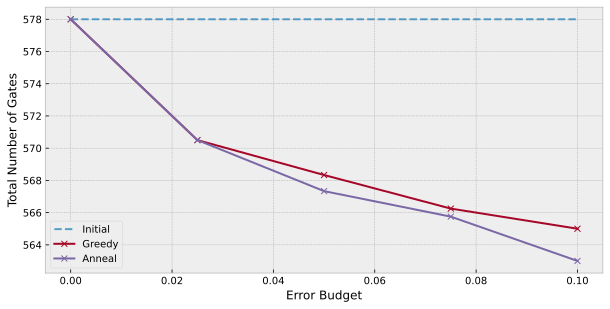

In [55]:
plt.style.use('bmh')
fig, ax = plt.subplots()
plt.plot(err_budget_list, avg_inital,'--', label='Initial', alpha=0.8)
plt.plot(err_budget_list, avg_greedy,'x-', label='Greedy')
plt.plot(err_budget_list, avg_anneal,'x-', label='Anneal')
plt.legend()
fig.set_figwidth(10)
#plt.yticks(np.arange(230,250,4))
plt.xlabel('Error Budget')
plt.ylabel('Total Number of Gates')

c:\Users\heave\OneDrive\Desktop\Approximation Internship\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\heave\OneDrive\Desktop\Approximation Internship\.venv\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0, 0.5, 'Number of Two-qubit Gates')

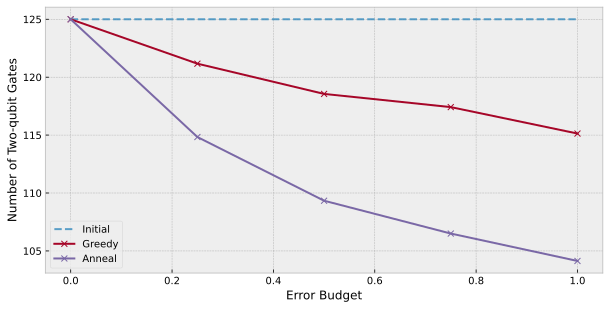

In [40]:
random.seed(1304)
np.random.seed(1304)

err_budget_list = np.linspace(0,1,5)
metric = 'twoqubit'
greedy_list = []
cold_list = []
anneal_list = []
inital_list = []

avg_inital = []
avg_cold = []
avg_greedy = []
avg_anneal = []

circ_dict = {}
for i in range(5):
    circ_dict[i] = random_control_phase(qubits=8, depth=100, p_noncliff = 0.3, p_cnot = 0, p_cphase = 0.5).to_basic_gates()

for err_budget in err_budget_list:
    for i in range(3):
        c_init = circ_dict[i]
    
        ### FULL REDUCE
        g = c_init.to_graph()
        zx.full_reduce(g)
        c = zx.extract_circuit(g)
        inital_list.append(c.stats_dict()[metric])

        ### GREEDY
        g = c_init.to_graph()
        zx.full_reduce(g)
        approximate(g, err_budget)
        c = zx.extract_circuit(g.clone())
        greedy_list.append(c.stats_dict()[metric])

        ### ANNEAL (ALGORITHM COLD)
        #g = c_init.to_graph()
        #zx.full_reduce(g)
        #approximate_anneal(g, err_budget, quiet=True, cold=True)
        #c = zx.extract_circuit(g)
        #cold_list.append(c.stats_dict()[metric])

        ### ANNEAL (HOT)
        g = c_init.to_graph()
        zx.full_reduce(g)
        approximate_anneal(g, err_budget, quiet=True)
        c = zx.extract_circuit(g)
        anneal_list.append(c.stats_dict()[metric])

    avg_inital.append(np.mean(inital_list))
    avg_greedy.append(np.mean(greedy_list))
    avg_cold.append(np.mean(cold_list))
    avg_anneal.append(np.mean(anneal_list))

plt.style.use('bmh')
fig, ax = plt.subplots()
plt.plot(err_budget_list, avg_inital,'--', label='Initial', alpha=0.8)
plt.plot(err_budget_list, avg_greedy,'x-', label='Greedy')
plt.plot(err_budget_list, avg_anneal,'x-', label='Anneal')  
plt.legend()
fig.set_figwidth(10)
plt.xlabel('Error Budget')
plt.ylabel('Number of Two-qubit Gates')

Text(0, 0.5, 'Number of Two-qubit Gates')

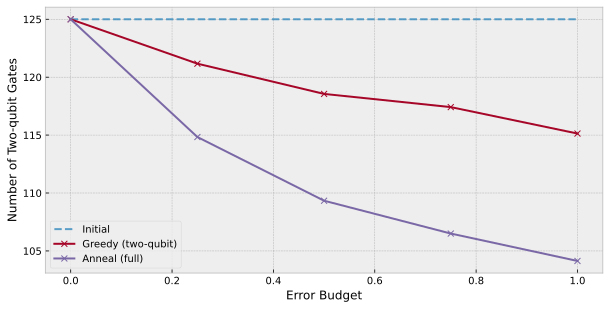

In [41]:
plt.style.use('bmh')
fig, ax = plt.subplots()
plt.plot(err_budget_list, avg_inital,'--', label='Initial', alpha=0.8)
plt.plot(err_budget_list, avg_greedy,'x-', label='Greedy (two-qubit)')
plt.plot(err_budget_list, avg_anneal,'x-', label='Anneal (full)')
plt.legend()
fig.set_figwidth(10)
plt.xlabel('Error Budget')
plt.ylabel('Number of Two-qubit Gates')

Finished benchmarking: 0.0
Finished benchmarking: 0.1111111111111111
Finished benchmarking: 0.2222222222222222
Finished benchmarking: 0.3333333333333333
Finished benchmarking: 0.4444444444444444
Finished benchmarking: 0.5555555555555556
Finished benchmarking: 0.6666666666666666
Finished benchmarking: 0.7777777777777777
Finished benchmarking: 0.8888888888888888
Finished benchmarking: 1.0
56
[np.float64(102.0), np.float64(79.8), np.float64(76.8), np.float64(71.8), np.float64(72.6), np.float64(67.8), np.float64(65.2), np.float64(61.8), np.float64(63.4), np.float64(64.2)]
[56, 52, 50, 46, 44, 44, 42, 42, 40, 40]
[102, 75, 74, 69, 70, 64, 59, 59, 57, 57]


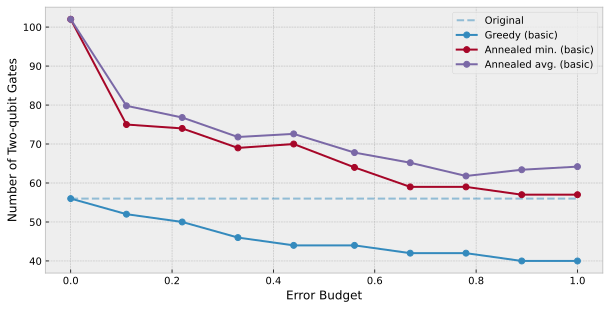

In [14]:
def anneal_greedy_algorithm_comp(circuit, err_budget_array, max_iter=10000, num_runs=5):
    bench_dict_original = {}
    bench_dict_anneal = {}
    bench_dict_greedy = {}
    total_error_greedy_list = []
    tq_count_anneal = []
    tq_count_anneal_min = []

    # Run for original
    c = zx.Circuit.load(circuit)
    bench_dict_original["Original"] = c.stats_dict()

    for err_budget in err_budget_array:
        # Run for anneal
        count = []
        min_count = float("inf")
        for _ in range(5):
            c = zx.Circuit.load(circuit)
            g = c.to_graph()
            zx.full_reduce(g)
            approximate_anneal(g, err_budget=err_budget, metric="twoqubit",quiet=True)
            c = zx.extract_circuit(g)
            bench_dict_anneal[f'{err_budget}'] = c.stats_dict()
            count.append(c.stats_dict()["twoqubit"])
            if c.stats_dict()["twoqubit"] < min_count:
                min_count = c.stats_dict()["twoqubit"]
        tq_count_anneal.append(np.mean(count))
        tq_count_anneal_min.append(min_count)

        # Run for greedy
        c = zx.Circuit.load(circuit)
        g = c.to_graph()
        total_error_greedy = greedy_basic_reduce(g, err_budget=err_budget, quiet=True)
        total_error_greedy_list.append(total_error_greedy)
        c = zx.extract_circuit(g)
        bench_dict_greedy[f'{err_budget}'] = c.stats_dict()

        print(f'Finished benchmarking: {err_budget}')

    return (bench_dict_original, tq_count_anneal, bench_dict_greedy, tq_count_anneal_min)

circuit_QFT8 = r'circuits_for_benchmarking\QFT8_before'
err_budget_array = np.linspace(0, 1, 10)
num_runs = 5  # Number of runs to average

bench_dict_original_QFT8, tq_count_anneal, bench_dict_greedy_QFT8, tq_count_anneal_min = anneal_greedy_algorithm_comp(circuit_QFT8, err_budget_array, max_iter=10000, num_runs=num_runs)

# Plotting line chart
plt.style.use('bmh')
metric_to_plot = "twoqubit"

tq_count_greedy = [bench_dict_greedy_QFT8[str(err)][metric_to_plot] for err in err_budget_array]
tq_count_original = bench_dict_original_QFT8["Original"]["twoqubit"]

print(tq_count_original)
print(tq_count_anneal)
print(tq_count_greedy)
print(tq_count_anneal_min)

x1 = np.arange(0, len(tq_count_anneal) + 2)
x2 = np.arange(0, len(tq_count_anneal)) + 2

fig, ax = plt.subplots()
err_budget_array_rounded = [float("%.2f" % i) for i in err_budget_array]
#plt.xticks(err_budget_array_rounded)

# Plot original as a dotted line
ax.hlines(tq_count_original, xmin=err_budget_array_rounded[0], xmax=err_budget_array_rounded[-1], linestyles='--', alpha=0.5, label='Original')

# Plot lines for each error budget
ax.plot(err_budget_array_rounded, tq_count_greedy, 'o-', label='Greedy (basic)')
ax.plot(err_budget_array_rounded, tq_count_anneal_min, 'o-', label='Annealed min. (basic)')
ax.plot(err_budget_array_rounded, tq_count_anneal, 'o-', label='Annealed avg. (basic)')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.xlabel('Error Budget')
plt.ylabel('Number of Two-qubit Gates')
fig.set_figwidth(10)
plt.savefig('qft8_benchmarking.png')
plt.show()

In [15]:
def anneal_greedy_algorithm_comp(circuit, err_budget_array, max_iter=10000, num_runs=5):
    bench_dict_original = {}
    bench_dict_anneal = {}
    bench_dict_greedy = {}
    total_error_greedy_list = []
    tq_count_anneal = []
    tq_count_anneal_min = []

    # Run for original
    c = zx.Circuit.load(circuit)
    bench_dict_original["Original"] = c.stats_dict()

    for err_budget in err_budget_array:
        # Run for anneal
        count = []
        min_count = float("inf")
        for _ in range(5):
            c = zx.Circuit.load(circuit)
            g = c.to_graph()
            zx.full_reduce(g)
            approximate_anneal(g, err_budget=err_budget, metric="twoqubit",quiet=True)
            c = zx.extract_circuit(g)
            bench_dict_anneal[f'{err_budget}'] = c.stats_dict()
            count.append(c.stats_dict()["twoqubit"])
            if c.stats_dict()["twoqubit"] < min_count:
                min_count = c.stats_dict()["twoqubit"]
        tq_count_anneal.append(np.mean(count))
        tq_count_anneal_min.append(min_count)

        # Run for greedy
        c = zx.Circuit.load(circuit)
        g = c.to_graph()
        total_error_greedy = approximate(g, err_budget=err_budget,metric="twoqubit", quiet=True)
        total_error_greedy_list.append(total_error_greedy)
        c = zx.extract_circuit(g)
        bench_dict_greedy[f'{err_budget}'] = c.stats_dict()

        print(f'Finished benchmarking: {err_budget}')

    return (bench_dict_original, tq_count_anneal, bench_dict_greedy, tq_count_anneal_min)

circuit_QFT8 = r'circuits_for_benchmarking\QFT8_before'
err_budget_array = np.linspace(0, 1, 10)
num_runs = 5  # Number of runs to average

bench_dict_original_QFT8, tq_count_anneal, bench_dict_greedy_QFT8, tq_count_anneal_min = anneal_greedy_algorithm_comp(circuit_QFT8, err_budget_array, max_iter=10000, num_runs=num_runs)

Finished benchmarking: 0.0
Finished benchmarking: 0.1111111111111111
Finished benchmarking: 0.2222222222222222
Finished benchmarking: 0.3333333333333333
Finished benchmarking: 0.4444444444444444
Finished benchmarking: 0.5555555555555556
Finished benchmarking: 0.6666666666666666
Finished benchmarking: 0.7777777777777777
Finished benchmarking: 0.8888888888888888
Finished benchmarking: 1.0


56
[np.float64(102.0), np.float64(80.0), np.float64(75.2), np.float64(72.6), np.float64(70.8), np.float64(63.4), np.float64(65.2), np.float64(61.4), np.float64(63.6), np.float64(60.2)]
[222, 209, 204, 196, 204, 192, 198, 185, 196, 185]
[102, 75, 73, 68, 67, 58, 59, 58, 57, 57]


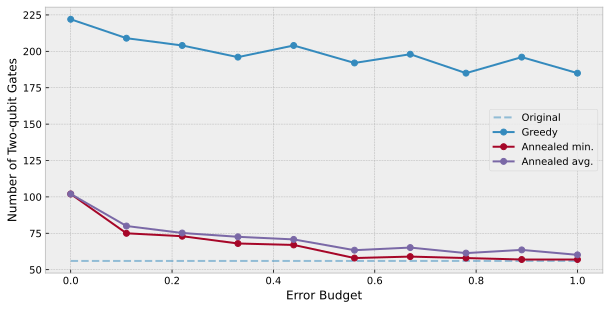

In [16]:
# Plotting line chart
plt.style.use('bmh')
metric_to_plot = "gates"

tq_count_greedy = [bench_dict_greedy_QFT8[str(err)][metric_to_plot] for err in err_budget_array]
tq_count_original = bench_dict_original_QFT8["Original"]["twoqubit"]

print(tq_count_original)
print(tq_count_anneal)
print(tq_count_greedy)
print(tq_count_anneal_min)

x1 = np.arange(0, len(tq_count_anneal) + 2)
x2 = np.arange(0, len(tq_count_anneal)) + 2

fig, ax = plt.subplots()
err_budget_array_rounded = [float("%.2f" % i) for i in err_budget_array]
#plt.xticks(err_budget_array_rounded)

# Plot original as a dotted line
ax.hlines(tq_count_original, xmin=err_budget_array_rounded[0], xmax=err_budget_array_rounded[-1], linestyles='--', alpha=0.5, label='Original')

# Plot lines for each error budget
ax.plot(err_budget_array_rounded, tq_count_greedy, 'o-', label='Greedy')
ax.plot(err_budget_array_rounded, tq_count_anneal_min, 'o-', label='Annealed min.')
ax.plot(err_budget_array_rounded, tq_count_anneal, 'o-', label='Annealed avg.')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.xlabel('Error Budget')
plt.ylabel('Number of Two-qubit Gates')
fig.set_figwidth(10)
plt.savefig('qft8_benchmarking.png')
plt.show()